In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df = pd.read_csv("C:/Users/AKSHAY S/OneDrive/Documents/Student_performance_data _.csv")

In [22]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [24]:
df.shape

(2392, 15)

In [25]:
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


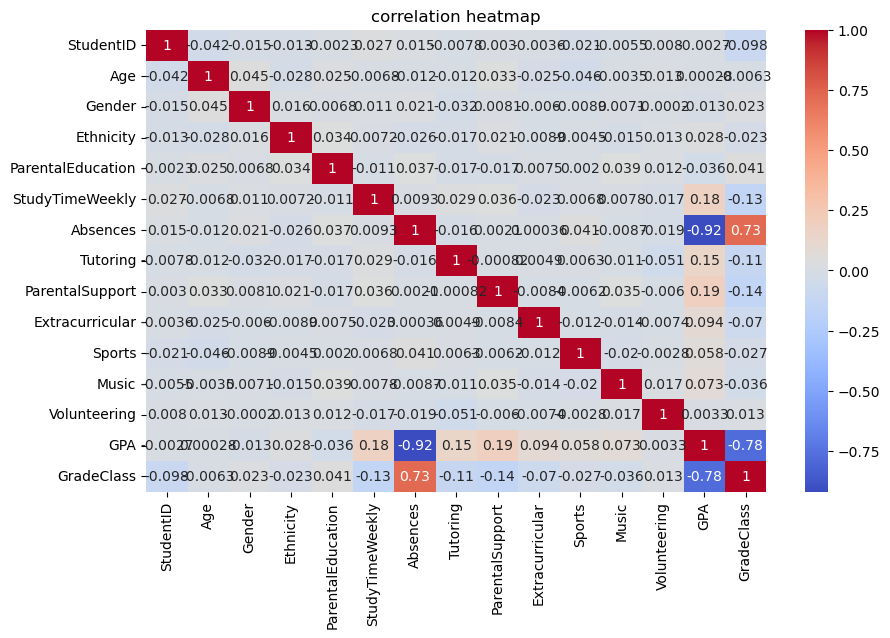

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("correlation heatmap")
plt.show()

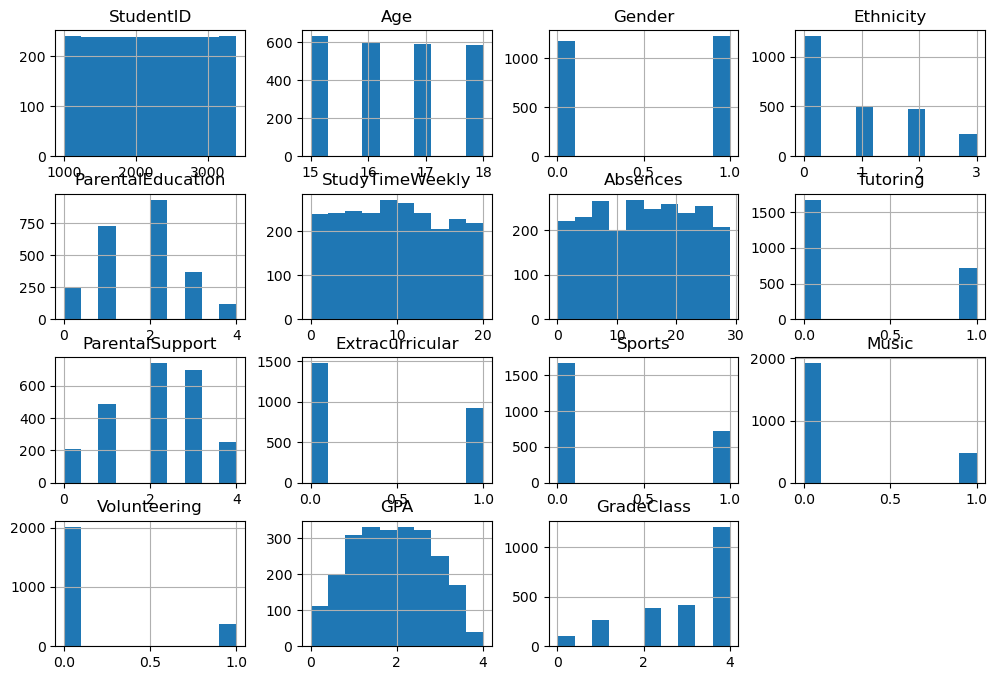

In [13]:
df.hist(figsize=(12,8))
plt.show()

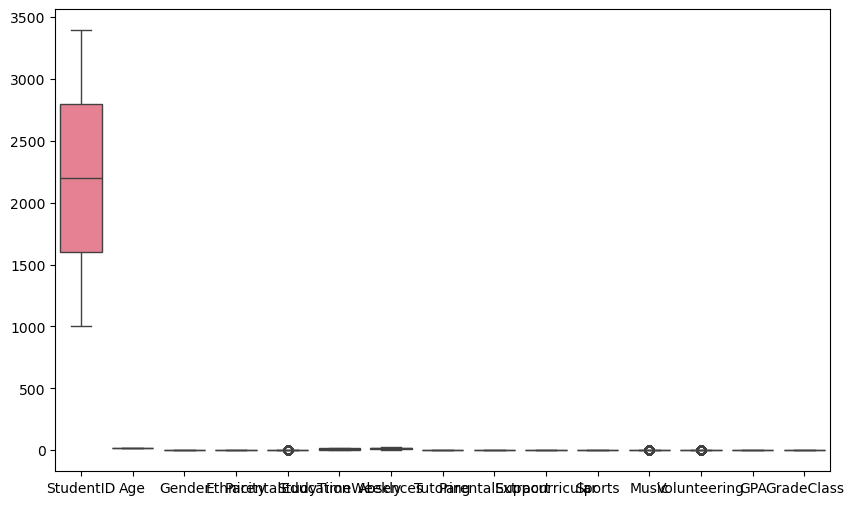

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.show()

In [15]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [20]:
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0],
inplace=True)
    

In [21]:
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [27]:
df.drop("StudentID",axis=1,inplace=True)

<function matplotlib.pyplot.show(close=None, block=None)>

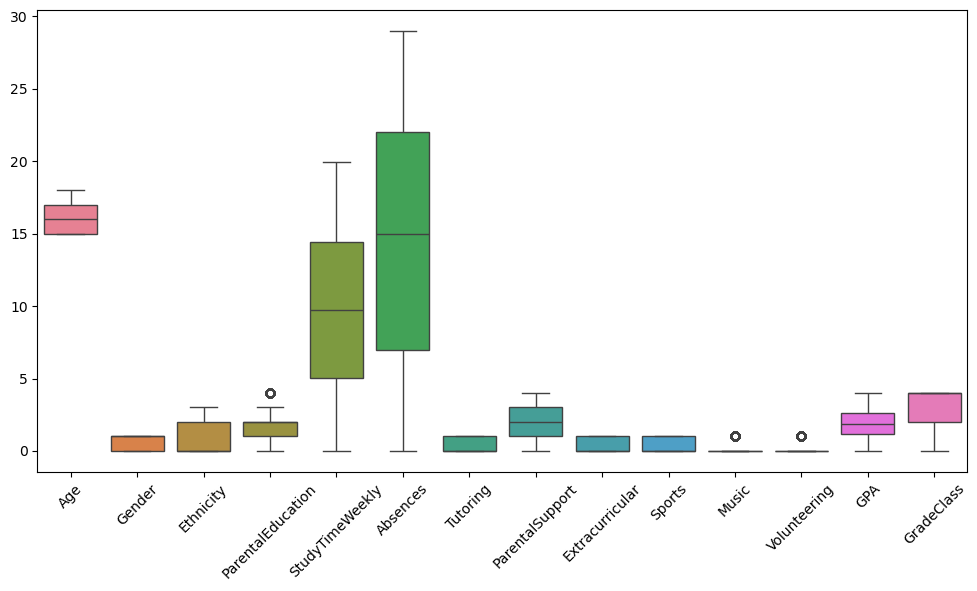

In [28]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show

In [30]:
num_df = df.select_dtypes(include=['number'])
Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((num_df<(Q1 - 1.5 * IQR))
|
          (num_df>(Q3 + 1.5 *IQR))).any(axis=1)]

<function matplotlib.pyplot.show(close=None, block=None)>

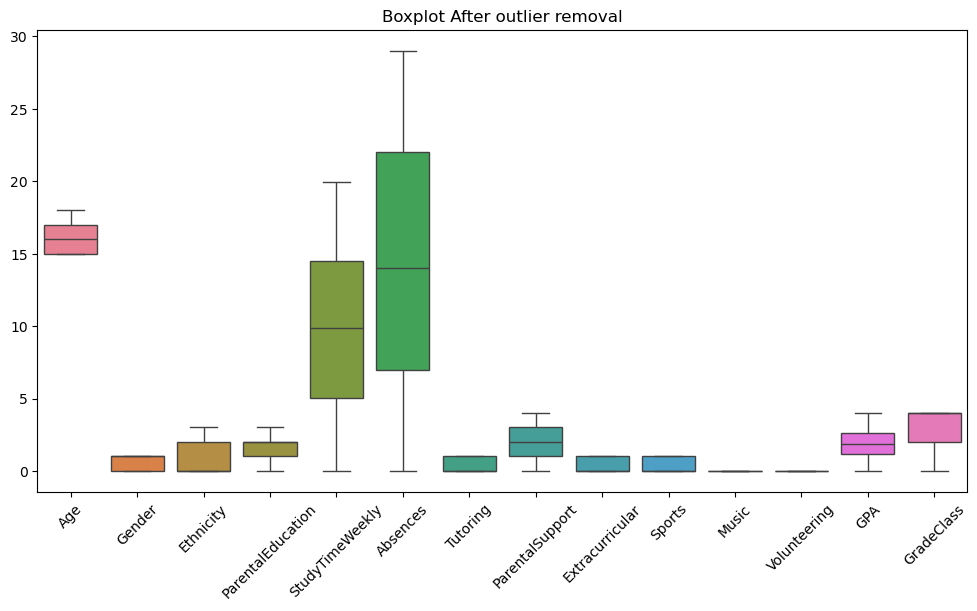

In [31]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot After outlier removal")
plt.show

In [33]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_cols = df.select_dtypes(include=['number'])
df[num_cols.columns]=scaler.fit_transform(num_cols)


In [34]:
df.head()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
1,1.000000,0.0,0.000000,0.333333,0.771270,0.000000,0.0,0.25,0.0,0.0,0.0,0.0,0.760729,0.25
2,0.000000,0.0,0.666667,1.000000,0.210718,0.896552,0.0,0.50,0.0,0.0,0.0,0.0,0.028151,1.00
3,0.666667,1.0,0.000000,1.000000,0.501965,0.482759,0.0,0.75,1.0,0.0,0.0,0.0,0.513555,0.75
4,0.666667,1.0,0.000000,0.666667,0.233840,0.586207,1.0,0.75,0.0,0.0,0.0,0.0,0.322015,1.00
5,1.000000,0.0,0.000000,0.333333,0.409979,0.000000,0.0,0.25,1.0,0.0,0.0,0.0,0.771046,0.25


In [36]:
for col in df.select_dtypes(include=['number']):
    df[col] = np.log1p(df[col])

In [37]:
df.head()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
1,0.526589,0.000000,0.000000,0.252844,0.452156,0.000000,0.000000,0.201424,0.000000,0.0,0.0,0.0,0.448351,0.201424
2,0.000000,0.000000,0.412656,0.526589,0.174972,0.494719,0.000000,0.340368,0.000000,0.0,0.0,0.0,0.027383,0.526589
3,0.412656,0.526589,0.000000,0.526589,0.341299,0.332109,0.000000,0.444440,0.526589,0.0,0.0,0.0,0.346748,0.444440
4,0.412656,0.526589,0.000000,0.412656,0.190729,0.379358,0.526589,0.444440,0.000000,0.0,0.0,0.0,0.246202,0.526589
5,0.526589,0.000000,0.000000,0.252844,0.295334,0.000000,0.000000,0.201424,0.526589,0.0,0.0,0.0,0.452075,0.201424


In [38]:
df.describe()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,1552.000000,1552.000000,1552.000000,1552.000000,1552.000000,1552.000000,1552.000000,1552.000000,1552.000000,1552.000000,1552.0,1552.0,1552.000000,1552.000000
mean,0.288533,0.265330,0.181147,0.333909,0.313074,0.315938,0.166934,0.329739,0.204935,0.163202,0.0,0.0,0.309990,0.420037
std,0.200131,0.263372,0.197161,0.151255,0.146091,0.151740,0.245107,0.146841,0.256828,0.243606,0.0,0.0,0.120362,0.143387
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.252844,0.202944,0.195750,0.000000,0.201424,0.000000,0.000000,0.0,0.0,0.223836,0.340368
50%,0.252844,0.526589,0.000000,0.412656,0.337113,0.332109,0.000000,0.340368,0.000000,0.000000,0.0,0.0,0.326656,0.526589
75%,0.412656,0.526589,0.412656,0.412656,0.435476,0.447585,0.526589,0.444440,0.526589,0.526589,0.0,0.0,0.408187,0.526589
max,0.526589,0.526589,0.526589,0.526589,0.526589,0.526589,0.526589,0.526589,0.526589,0.526589,0.0,0.0,0.526589,0.526589


In [39]:
df.to_csv("cleaned_student_performance.csv",index=False)